In [11]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
class Value:

    def __init__(self,data, _children = (), _op =() , label = "") -> None:
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        return f"Value(data={self.data})"

    def __add__(self, other) -> Value:
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward() -> None:
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __radd__(self, other)-> Value: # other + self
        return self + other
    
    def __mul__(self, other) -> Value:
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), '*')

        def _backward() ->None:
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward
        return out
    
    def __rmul__(self, other) -> Value: # other * self
        return self * other
    
    def __pow__(self,other) -> Value:
        assert isinstance(other, (int, float)), "only support integer and float"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward() -> None:
            self.grad += other * self.data ** (other -1) * out.grad

        out._backward = _backward
        return out
    
    def __neg__(self) -> Value:
        return self * -1

    def __sub__(self, other) -> Value:
        return self + (-other)

    def __rsub__(self, other) -> Value:
        return (-self) + other
    
    def __truediv__(self, other) -> Value:
        return self * (other ** -1)

    def __rtruediv__(self, other) -> Value:
        return (self ** -1) * other
    
    def exp(self) -> Value:
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward() -> None:
            self.grad += out.data * out.grad
        
        out._backward = _backward
        return out

    def tanh(self) -> Value: 
        x = self.data
        tanh = (math.exp(2*x) - 1) /(math.exp(2*x) + 1)
        out = Value(tanh, (self, ), 'tanh')

        def _backward() -> None:
            self.grad += (1 - out.data ** 2) * out.grad
            
        out._backward = _backward
        return out
    
    def backward(self) -> None:
        visited = set()
        topo = []
        def topo_sort(node) -> None:

            if node in visited:
                return
            visited.add(node)
            for child in node._prev:

                topo_sort(child)
            topo.append(node)

        topo_sort(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [13]:
from graphviz import Digraph


def trace(root):# -> tuple[set[Any], set[Any]]:# -> tuple[set[Any], set[Any]]:# -> tuple[set[Any], set[Any]]:# -> tuple[set[Any], set[Any]]:# -> tuple[set[Any], set[Any]]:
    # build node and edges graph
    nodes, edges = set(), set()
    def build(v) -> None:
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot  = Digraph(format= 'svg', graph_attr={'rankdir': 'LR'}) #LR is Left to Right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        #for any value in graph create a rectangular node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f  }" % (n.label, n.data, n.grad),shape='record')
        if n._op:
            # if it is from another operation create a operation node for it 
            dot.node(name = uid + n._op, label = n._op)
            #and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1,n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot



In [14]:
#inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias b
b = Value(6.8813735870195432, label='b')
#x1*w1 and x2*w2
x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
#compute x1*w1 + x2*w2 
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label= 'x1*w1 + x2*w2'
#compute (x1* w1 + x2*w2) + b
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp(); e.label = 'e^2n'
o = (e - 1) / (e + 1); o.label = 'o'
o.backward()

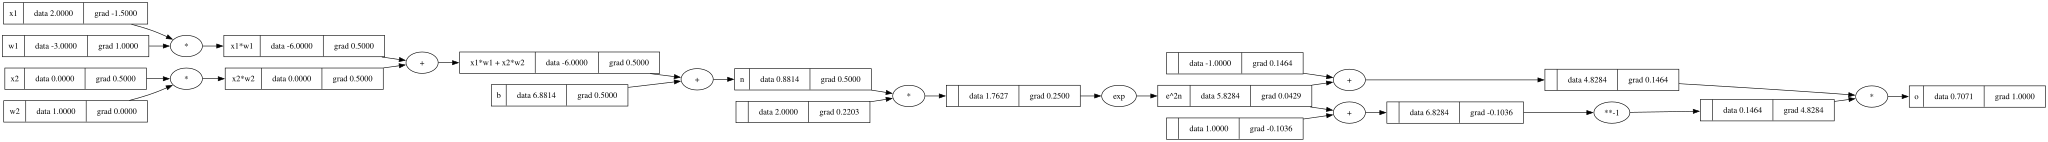

In [15]:
draw_dot(o)

In [16]:
import random
class Neuron:

    def __init__(self, nin) -> None:
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x) -> Value:
        act = sum((xi * wi for wi,xi in zip(self.w,x)), self.b)
        out = act.tanh()
        return out

    def parameters(self) -> list[Value]:
        return self.w + [self.b]
    

class Layer:

    def __init__(self,nin,nout) -> None:
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x)-> Value | list[Value]:
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return[p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:

    def __init__(self, nin, nouts) -> None:
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x)-> Value | list[Value]:
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return[p for layer in self.layers for p in layer.parameters()]
    

In [17]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.9174693547413882)

In [18]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # targets

In [19]:
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))  # type: ignore

    # backward pass
    for p in n.parameters():
        p.grad = 0
    loss.backward()  # type: ignore

    # gradient update
    for p in n.parameters():
        p.data += -0.05 * p.grad
    print(k, loss.data) # type: ignore

0 5.427571319556623
1 3.9549002357005336
2 3.4576982485938723
3 2.734406195343674
4 1.6536675178172713
5 0.9293246381754501
6 0.5807586584249617
7 0.4025340103915498
8 0.301123263985766
9 0.23737992409833758
10 0.19426379494943144
11 0.16346139029987142
12 0.14050854004297295
13 0.1228269293623476
14 0.1088366315381344
15 0.09752141963253448
16 0.08820084184611576
17 0.08040364134743491
18 0.07379394928003002
19 0.06812641976720808


In [20]:
ypred

[Value(data=0.9159945348704225),
 Value(data=-0.895506397616555),
 Value(data=-0.8427927334925922),
 Value(data=0.8405118687369785)]